In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
import scipy

# Part 1

In [2]:
rng = np.random.default_rng(30)
n = 10

# Generate points
#X = rng.uniform(-10,10,size=(n,2))
angles = np.linspace(0,2*np.pi,n+1)
X = np.column_stack([np.cos(angles), np.sin(angles)])

# Distance matrix
A = scipy.spatial.distance_matrix(X,X,p=2)

# Route
#route = np.arange(n)
route = rng.permutation(n)

def f(route,A):
    cost = 0
    for i in range(len(route)):
        x = route[i]
        if i == len(route) -1:
            y = route[0]
        else:
            y = route[i+1]
        cost += A[x,y]
        
    return cost

def swap(arr, idx1,idx2):
    arr[[idx1,idx2]] = arr[[idx2,idx1]]

def plot_route(route,X, title):
    plt.plot(X[route, 0], X[route, 1],"x-", color="blue")
    plt.plot(X[route[[-1,0]], 0], X[route[[-1,0]], 1],"x-", color="blue")
    plt.title(title)
    plt.show()

print(f"Cost initial: {f(route, A)}")

Cost initial: 11.174417973339365


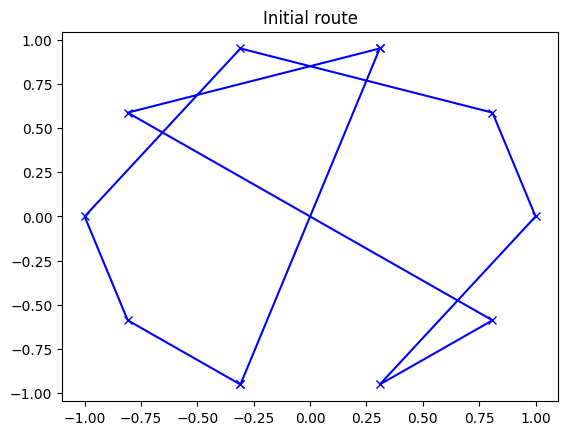

In [3]:
plot_route(route,X,"Initial route")

In [4]:
def annealing_algorithm(K,X):
    rng = np.random.default_rng(30)
    n = len(X)

    # Cost matrix
    A = scipy.spatial.distance_matrix(X,X,p=2)

    # Inital route
    route = np.arange(n)

    for k in range(K):
        Tk = 1/np.sqrt(1+k)

        # Swap two random idecies
        route_prop = np.copy(route)
        idx1 = rng.integers(0, n)

        while True:
            idx2 = rng.integers(0, n)
            if idx1 != idx2:
                break
        
        swap(route_prop, idx1, idx2)

        # State
        fY = f(route_prop,A)
        fX = f(route, A)

        if fY <= fX:
            route = route_prop
        else:
            alpha = np.exp(-(fY-fX)/Tk)
            if rng.uniform(0,1) <= alpha:
                route = route_prop
    
    return route

In [5]:
route_final = annealing_algorithm(1000,X)

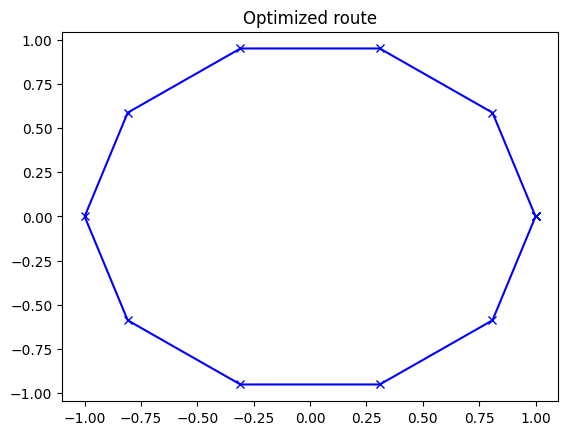

In [6]:
plot_route(route_final,X, "Optimized route")

# Part 2

In [7]:
def annealing_algorithm(K,A):
    rng = np.random.default_rng(20)
    n = len(A)

    # Inital route
    route = np.arange(n)

    for k in range(K):
        Tk = 1/np.sqrt(1+k)

        # Swap two random idecies
        route_prop = np.copy(route)
        idx1 = rng.integers(0, n)

        while True:
            idx2 = rng.integers(0, n)
            if idx1 != idx2:
                break
        
        swap(route_prop, idx1, idx2)

        # State
        fY = f(route_prop,A)
        fX = f(route, A)

        if fY <= fX:
            route = route_prop
        else:
            alpha = np.exp(-(fY-fX)/Tk)
            if rng.uniform(0,1) <= alpha:
                route = route_prop
    
    return route

In [8]:
# Load Cost matrix from provided 
A = np.genfromtxt("cost.csv", delimiter=",")

In [9]:
route_final = annealing_algorithm(1000, A)

In [10]:
route_final, f(route_final,A)

(array([19,  2, 18, 14,  1,  8, 13,  7,  4, 15,  9,  0, 12,  3,  5, 11, 17,
         6, 16, 10]),
 np.float64(810.0))

# New cooling scheme

In [11]:
def annealing_algorithm(K,A):
    rng = np.random.default_rng(20)
    n = len(A)

    # Inital route
    route = np.arange(n)

    for k in range(K):
        Tk = 1/np.log(2+k)

        # Swap two random idecies
        route_prop = np.copy(route)
        idx1 = rng.integers(0, n)

        while True:
            idx2 = rng.integers(0, n)
            if idx1 != idx2:
                break
        
        swap(route_prop, idx1, idx2)

        # State
        fY = f(route_prop,A)
        fX = f(route, A)

        if fY <= fX:
            route = route_prop
        else:
            alpha = np.exp(-(fY-fX)/Tk)
            if rng.uniform(0,1) <= alpha:
                route = route_prop
    
    return route

In [12]:


print(f"Cost initial: {f(route, A)}")
route_final = annealing_algorithm(1000, A)
route_final, f(route_final,A)

Cost initial: 1787.0


(array([19,  2, 18, 14,  1,  8, 13,  7,  4, 15,  9,  0, 12,  3,  5, 11, 17,
         6, 16, 10]),
 np.float64(810.0))

# New propsal mechanism with old cooling scheme

In [15]:
def annealing_algorithm(K,A):
    rng = np.random.default_rng(20)
    n = len(A)

    # Inital route
    route = np.arange(n)

    for k in range(K):
        Tk = 1/np.sqrt(1+k)

        # random permutations
        route_prop = rng.permutation(n)

        # State
        fY = f(route_prop,A)
        fX = f(route, A)

        if fY <= fX:
            route = route_prop
        else:
            alpha = np.exp(-(fY-fX)/Tk)
            if rng.uniform(0,1) <= alpha:
                route = route_prop
    
    return route

In [17]:
print(f"Cost initial: {f(route, A)}")
route_final = annealing_algorithm(1000, A)
route_final, f(route_final,A)

Cost initial: 1787.0


(array([ 4,  9, 12,  7,  1, 14, 15, 13, 17, 19,  6, 16, 11,  5, 10,  2,  3,
         0,  8, 18]),
 np.float64(1841.0))

# New propsal mechanism with new cooling scheme

In [18]:
def annealing_algorithm(K,A):
    rng = np.random.default_rng(20)
    n = len(A)

    # Inital route
    route = np.arange(n)

    for k in range(K):
        Tk = 1/np.log(2+k)

        # random permutation
        route_prop = rng.permutation(n)
        

        # State
        fY = f(route_prop,A)
        fX = f(route, A)

        if fY <= fX:
            route = route_prop
        else:
            alpha = np.exp(-(fY-fX)/Tk)
            if rng.uniform(0,1) <= alpha:
                route = route_prop
    
    return route

print(f"Cost initial: {f(route, A)}")
route_final = annealing_algorithm(1000, A)
route_final, f(route_final,A)

Cost initial: 1787.0


(array([ 4,  9, 12,  7,  1, 14, 15, 13, 17, 19,  6, 16, 11,  5, 10,  2,  3,
         0,  8, 18]),
 np.float64(1841.0))